In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import pandas as pd
import os

In [17]:
PROJECT_ROOT = Path("/home/jesush/projects/xai_nlp_colab/xai-nlp")
RESULTS_ROOT = PROJECT_ROOT / "new_results" / "distilbert-base-uncased-finetuned-sst-2-english"
METHODS      = ["Occlusion", "Shap", "LIME", "IG"]
PATHS = {
    "project_root": PROJECT_ROOT,
    "results":      PROJECT_ROOT / "new_results",
    "plots":        PROJECT_ROOT / "plots",
}

for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

# Prefer the new `trapezoid` name; fallback to `trapz` for older NumPy versions
_trapz_func = getattr(np, 'trapezoid', np.trapz)

In [3]:
CONFIGS = [
    # base: n_not = 1, 2, 3
    ("base",        "sentence_not_1",             "Base  n=1",        {-2: "not"}),
    ("base",        "sentence_not_2",             "Base  n=2",        {-3: "first not", -2: "second not"}),
    ("base",        "sentence_not_3",             "Base  n=3",        {-4: "first not", -3: "second not", -2: "third not"}),

    # contraction: n_not = 1, 2
    ("contraction", "sentence_not_1_contraction", "Contraction  n=1", {-2: "not"}),
    ("contraction", "sentence_not_2_contraction", "Contraction  n=2", {-3: "first not", -2: "second not"}),

    # not_at: n_not = 1, 2
    ("not_start",   "sentence_not_beginning",   "Not-at-beginning",      {-2: "not"}),
    ("not_start", "sentence_not_beginning_not", "Not-at-beginning-not", {0: "NOT", -1: "adj not"}),

    # aux_not: auxiliary not (pos 2) + adjectival not (pos -2, -3...)
    ("aux_not",     "sentence_not_0_aux",         "Aux  n=0",         {2: "aux not"}),
    ("aux_not",     "sentence_not_1_aux",         "Aux  n=1",         {2: "aux not", -2: "adj not"}),
]

## Plots

In [25]:
def plot_not_attribution(model_name, short_name, config):
    results_root = PROJECT_ROOT / "new_results" / model_name

    PALETTE = ["#e94560", "#0f9b8e", "#f5a623"]  # extend if a config has 3 positions
    method_order = ["Occlusion", "LIME", "Shap", "IG"]

    base_configs = [c for c in CONFIGS if " ".join(c[0].split()).startswith(config)]
    print(base_configs)

    for folder, filename, label, positions in base_configs:
        fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False, facecolor="white")
        x = np.linspace(0, 1, 2000)

        for ax, method in zip(axes, method_order):
            ax.set_facecolor("#eef0f4")

            path = results_root / method / folder / f"{filename}.pkl"
            if not path.exists():
                print(f"Missing: {path}")
                continue

            with open(path, "rb") as f:
                distrib = pickle.load(f)

            for j, (pos, pos_label) in enumerate(positions.items()):
                scores = [arr[pos] for arr in distrib]
                kde    = gaussian_kde(scores)
                p      = kde(x)
                
                p     /= _trapz_func(p, x)
                    
                ax.plot(x, p, color=PALETTE[j], linewidth=2, label=pos_label)
                ax.fill_between(x, p, color=PALETTE[j], alpha=0.2)

            method = method.upper() if method == "Shap" else method
            ax.set_title(method, fontsize=22)
            ax.set_xlabel("Attribution score", fontsize=22)
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.legend(fontsize=16)
            ax.tick_params(axis='both', labelsize=16)
            ax.grid(alpha=0.3, color="white", linewidth=1)
            ax.set_axisbelow(True)

        axes[0].set_ylabel("Density", fontsize=24)

        # fig.suptitle(short_name.capitalize(), fontsize=26, y=0.99)
        plt.tight_layout()

        n = " ".join(label.split()).split("n=")[-1]  # extracts "1", "2", or "3"
        out_dir = PATHS['plots'] / "normalized" / model_name
        os.makedirs(out_dir, exist_ok=True)
        plt.savefig(out_dir / f"{config}_{n}_{short_name}.pdf", format="pdf", bbox_inches="tight")
        plt.show()

MODELS = {"siebert": "siebert/sentiment-roberta-large-english", "distilbert": "distilbert-base-uncased-finetuned-sst-2-english", "roberta": "roberta-large-sst2"}

[('base', 'sentence_not_1', 'Base  n=1', {-2: 'not'}), ('base', 'sentence_not_2', 'Base  n=2', {-3: 'first not', -2: 'second not'}), ('base', 'sentence_not_3', 'Base  n=3', {-4: 'first not', -3: 'second not', -2: 'third not'})]


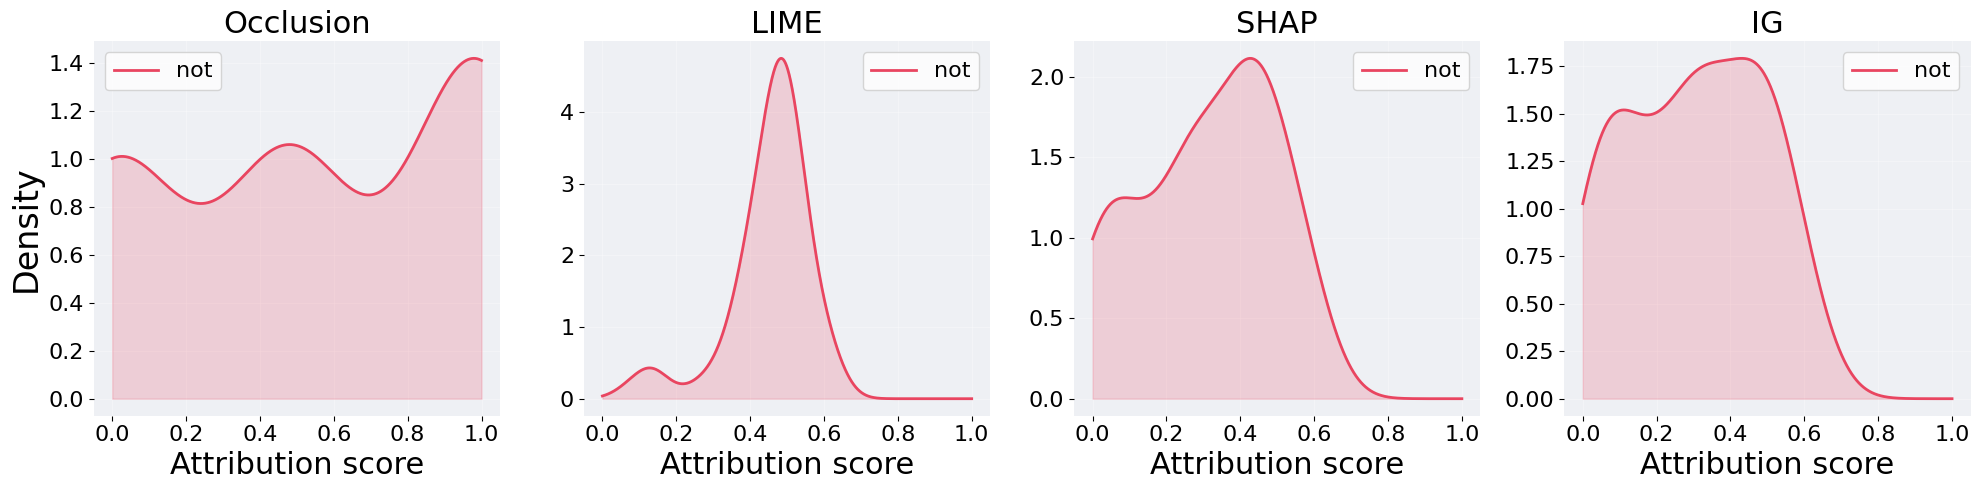

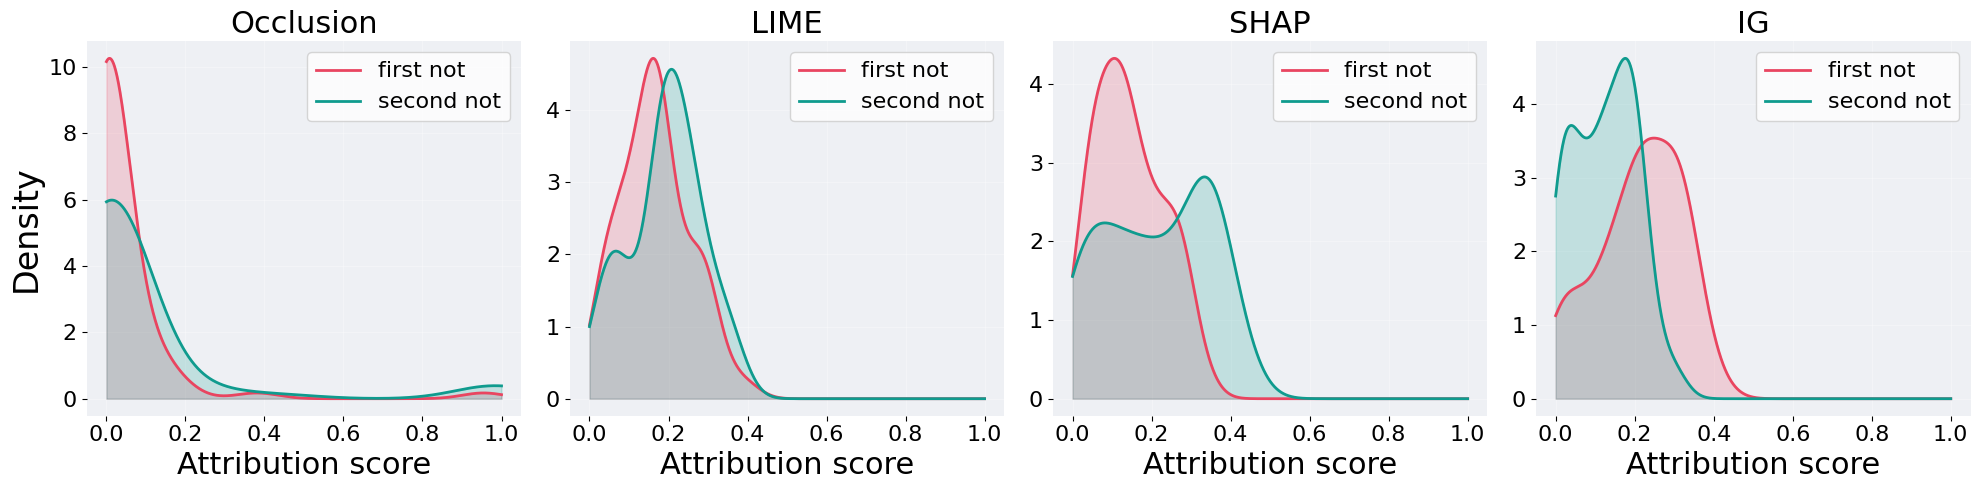

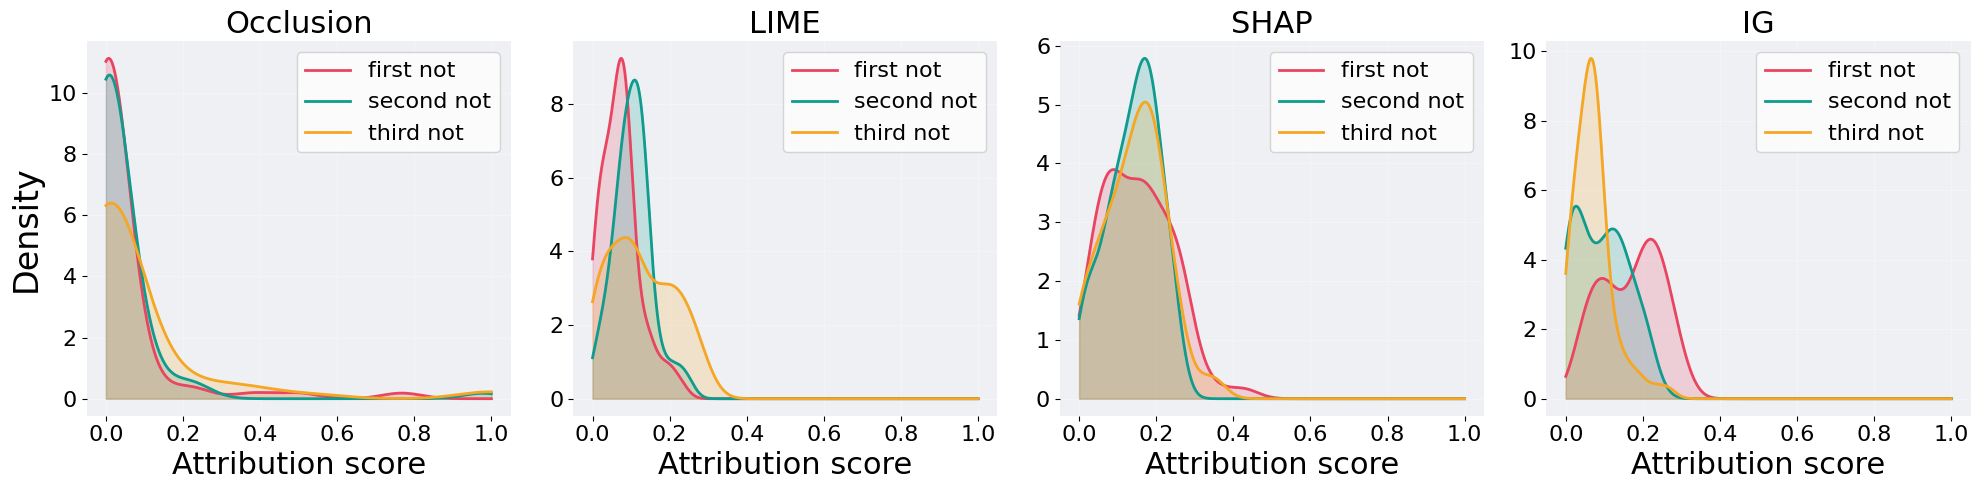

In [32]:
# Remove the indexes to generate all combinations
for short_model_name in ["distilbert", "siebert"][:1]:
    for short_config in ["base", "contraction", "not_start", "aux_not"][:1]:
        plot_not_attribution(MODELS[short_model_name], short_model_name, short_config)

## Distance computation

In [11]:
def compute_l1_distance(data1,data2,total_variation=False):
    """
    Given two arrays, infer the distribution with Gaussian KDE and compute the L1 distance between them.
    """
    kde_1 = gaussian_kde(data1)
    kde_2 = gaussian_kde(data2)
    x = np.linspace(0, 1, 2000)
    p = kde_1(x)
    q = kde_2(x)
    p /= np._trapz_func(p, x)
    q /= np._trapz_func(q, x)
    l1 = np._trapz_func(np.abs(p - q), x)

    if total_variation:
        return 0.5 * l1

    return l1

def k_metric(data1, data2):
    if np.allclose(data1, data1[0]) or np.allclose(data2, data2[0]): # if no variability then we set 0, KDE cannot be computed
        return 0.0
    kde1 = gaussian_kde(data1)
    kde2 = gaussian_kde(data2)
    x = np.linspace(0, 1, 2000)
    p = kde1(x)
    q = kde2(x)
    p /= np._trapz_func(p, x)
    q /= np._trapz_func(q, x)
    dissimilarity = 1 - np._trapz_func(np.minimum(p, q), x) / np._trapz_func(np.maximum(p, q), x)
    return dissimilarity

def kl_divergence(data1, data2, eps=1e-10):
    """
    Given two arrays, infer the distribution with Gaussian KDE and compute the KL divergence between them.
    """
    kde1 = gaussian_kde(data1)
    kde2 = gaussian_kde(data2)
    x = np.linspace(0, 1, 2000)
    p = kde1(x)
    q = kde2(x)
    p /= np._trapz_func(p, x)
    q /= np._trapz_func(q, x)
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    kl = np._trapz_func(p * np.log(p / q), x)

    return kl

In [12]:
from scipy.stats import gaussian_kde
from itertools import combinations

# feel free to add new cross-config comparisons
CROSS_CONFIGS = [
    ("Base n=1", -2, "Contraction n=1", -2),
    ("Base n=1", -2, "Not-at-beginning",      -2),
    ("Base n=1", -2, "Aux n=1",         -2),
    ("Contraction n=1", -2, "Not-at-beginning", -2),
    ("Contraction n=1", -2, "Aux n=1",    -2),
]

def compute_metrics_between_nots(model_name):
    results_root = PROJECT_ROOT / "new_results" / model_name
    records = []

    # helper to load scores for a config
    def load_scores(folder, filename, pos):
        path = results_root / method / folder / f"{filename}.pkl"
        if not path.exists():
            return None
        with open(path, "rb") as f:
            distrib = pickle.load(f)
        return [arr[pos] for arr in distrib]

    # build a lookup: label -> (folder, filename, positions)
    config_lookup = {label: (folder, filename, positions)
                     for folder, filename, label, positions in CONFIGS}
    
    config_lookup = { " ".join(k.split()): v for k, v in config_lookup.items() }
    
    print(list(config_lookup.keys()))       
    

    for method in METHODS:

        # ── within-config: compare multiple nots ──────────────────────────
        for folder, filename, label, positions in CONFIGS:
            if len(positions) < 2:
                continue

            scores_per_pos = {}
            for pos, pos_label in positions.items():
                s = load_scores(folder, filename, pos)
                if s is not None:
                    scores_per_pos[pos_label] = s

            for a, b in combinations(list(scores_per_pos.keys()), 2):
                data1, data2 = scores_per_pos[a], scores_per_pos[b]
                records.append({
                    "comparison": "within_config",
                    "config_a":   label,
                    "config_b":   label,
                    "pair":       f"{a} vs {b}",
                    "method":     method,
                    "L1":         compute_l1_distance(data1, data2),
                    "K":          k_metric(data1, data2),
                    "KL":         kl_divergence(data1, data2),
                })

        # ── cross-config: compare same "not" position across configs ──────
        for label_a, pos_a, label_b, pos_b in CROSS_CONFIGS:
            # if label_a not in config_lookup or label_b not in config_lookup:
            #     continue
            folder_a, filename_a, _ = config_lookup[label_a]
            folder_b, filename_b, _ = config_lookup[label_b]

            data1 = load_scores(folder_a, filename_a, pos_a)
            data2 = load_scores(folder_b, filename_b, pos_b)

            if data1 is None or data2 is None:
                continue

            records.append({
                "comparison": "cross_config",
                "config_a":   label_a,
                "config_b":   label_b,
                "pair":       f"pos {pos_a} vs pos {pos_b}",
                "method":     method,
                "L1":         compute_l1_distance(data1, data2),
                "K":          k_metric(data1, data2),
                "KL":         kl_divergence(data1, data2),
            })

    df = pd.DataFrame(records).sort_values("method").reset_index(drop=True)
    os.makedirs("new_results", exist_ok=True)
    df.to_csv(f"new_results/{model_name}/metrics_between_nots.csv", index=False)
    return df

In [13]:
df_metrics = compute_metrics_between_nots("siebert/sentiment-roberta-large-english")
df_metrics

['Base n=1', 'Base n=2', 'Base n=3', 'Contraction n=1', 'Contraction n=2', 'Not-at-beginning', 'Not-at-beginning-not', 'Aux n=0', 'Aux n=1']


,comparison,config_a,config_b,pair,method,L1,K,KL
0,cross_config,Contraction n=1,Aux n=1,pos -2 vs pos -2,IG,0.139898,0.130752,0.040122
1,within_config,Base n=2,Base n=2,first not vs second not,IG,0.098607,0.093973,0.019855
2,within_config,Base n=3,Base n=3,first not vs second not,IG,0.218378,0.196881,0.056585
3,within_config,Base n=3,Base n=3,first not vs third not,IG,0.108539,0.102952,0.026727
4,within_config,Base n=3,Base n=3,second not vs third not,IG,0.158601,0.146948,0.237945
5,cross_config,Base n=1,Aux n=1,pos -2 vs pos -2,IG,0.247499,0.220244,0.228874
6,within_config,Not-at-beginning-not,Not-at-beginning-not,NOT vs adj not,IG,0.502675,0.401710,0.205095
7,within_config,Aux n=1,Aux n=1,aux not vs adj not,IG,0.212189,0.191836,0.062126
8,cross_config,Base n=1,Contraction n=1,pos -2 vs pos -2,IG,0.254660,0.225897,0.319769
9,within_config,Contraction n=2,Contraction n=2,first not vs second not,IG,0.205052,0.185984,0.030800
